# MNIST Interpolation

We have trained our neural network.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import yaml
import lightning as pl
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import DataLoader
from torchvision import transforms

from ciflows.datasets.causalmnist import CausalMNIST
from ciflows.eval import load_model
from ciflows.reduction.resnetvae_mnist import DeepResNetMNISTVAE
from ciflows.reduction import make_mnist_nf_model


/home/adam2392/miniforge3/envs/ciflowsv2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def load_experiment_config(config_path):
    """Load experiment configuration from a YAML file."""
    with open(config_path, "r") as file:
        config = yaml.safe_load(file)
    return config

In [4]:
print(torch.__version__)

2.5.1.post207


In [5]:

# Option 2: Display the grid using matplotlib
def tensor_to_numpy(image_tensor):
    # Convert from tensor to NumPy for plotting
    image = image_tensor.cpu().permute(1, 2, 0)  # (C, H, W) -> (H, W, C)
    return image.numpy()

## Setup - directories and GPU selection

In [6]:
root = Path("/Users/adam2392/pytorch_data/")
root = Path('/local/eb/adam2392/')
seed_offset = 1

# set seed
seed = 1234
np.random.seed(seed + seed_offset)
pl.seed_everything(seed + seed_offset, workers=True)

image_size = 128
latent_dim = 48
num_blocks_per_stage = 3
debug = False

if torch.cuda.is_available():
    device = torch.device("cuda")
    accelerator = "cuda"

    # Get the index of the current device
    device_index = 2
    device = torch.device(f"cuda:{device_index}")
    print(f"Current CUDA device index: {device_index}")

    # Get the name of the current device
    device_name = torch.cuda.get_device_name(device_index)
    print(f"Current CUDA device name: {device_name}")

    num_devices = torch.cuda.device_count()
    device_names = [torch.cuda.get_device_name(i) for i in range(num_devices)]
    print('NUm devices: ', num_devices)
    print(device_names)
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    accelerator = "mps"
else:
    device = torch.device("cpu")
    accelerator = "cpu"

print(f"Using device: {device}")
print(f"Using accelerator: {accelerator}")

Seed set to 1235


Current CUDA device index: 2
Current CUDA device name: NVIDIA H100 80GB HBM3
NUm devices:  8
['NVIDIA H100 80GB HBM3', 'NVIDIA H100 80GB HBM3', 'NVIDIA H100 80GB HBM3', 'NVIDIA H100 80GB HBM3', 'NVIDIA H100 80GB HBM3', 'NVIDIA H100 80GB HBM3', 'NVIDIA H100 80GB HBM3', 'NVIDIA H100 80GB HBM3']
Using device: cuda:2
Using accelerator: cuda


## Load relevant model

Here, we load the already trained models: ResNet-VAE, causal NF and the diffusion deblurring model

In [12]:
# Paths and Experiment Settings
root = Path("/local/eb/adam2392/")
exp_name = "causalmnist_nf_exp6"
model_root = root / 'CausalMNIST' / "nf_reduction" / exp_name
nf_config_path = model_root / "experiment_config.yaml"
nf_config = load_experiment_config(nf_config_path)

# Load Pretrained VAE Model
vae_checkpoint_dir = (
    Path(nf_config["vae"]["checkpoint_dir"]) / nf_config["vae"]["experiment_name"]
)
vae_config_path = vae_checkpoint_dir / "experiment_config.yaml"
vae_config = load_experiment_config(vae_config_path)
vae_checkpoint_file = vae_checkpoint_dir / nf_config["vae"]["vae_checkpoint_fname"]

img_size = nf_config["data"]["img_size"]
vae_model = DeepResNetMNISTVAE(
    latent_dim=vae_config["model"]["latent_dim"],
    num_blocks_per_stage=vae_config["model"]["num_blocks_per_stage"],
)
vae_model, _ = load_model(vae_model, vae_checkpoint_file, device)
vae_model.to(device).eval()

# Initialize NF Model
nf_model = make_mnist_nf_model(
    K=nf_config["model"]["num_flows"], trainable_edges=nf_config["model"]["trainable_edges"]
).to(device)

# Load NF Checkpoint if Available
nf_checkpoint_dir = root / 'CausalMNIST' / "nf_reduction" / nf_config["exp_name"]
start_epoch = 1
nf_checkpoint_file = nf_checkpoint_dir / 'model_epoch_1840.pt'
nf_model, _ = load_model(nf_model, nf_checkpoint_file, device)

/home/adam2392/projects/ciflows/ciflows/eval.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(model_path, map_location=device)


Model loaded from /local/eb/adam2392/CausalMNIST/vae_reduction/causalmnist_exp1_betamax01/final_model.pt
Model loaded from /local/eb/adam2392/CausalMNIST/nf_reduction/causalmnist_nf_exp6/model_epoch_1840.pt


## Setup Dataset and DataLoader

Here, we'll load in the CelebA dataset and specifically a batch of blond hair images
and a batch of black hair images.

In [13]:
img_size = 32
graph_type = 'chain'

# Define the image transformations
image_transform = transforms.Compose(
    [
        transforms.Resize((img_size, img_size)),  # Resize images to 128x128
        transforms.CenterCrop(img_size),  # Ensure square crop
        transforms.ToTensor(),  # Convert images to PyTorch tensors
        # transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    ]
)
causal_mnist_dataset = CausalMNIST(
    root=root,
    graph_type=graph_type,
    transform=image_transform,
    fast_dev_run=False,  # Set to True for debugging
)

/tmp/ipykernel_2627979/616578323.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  meta_labels = torch.tensor(meta_labels)


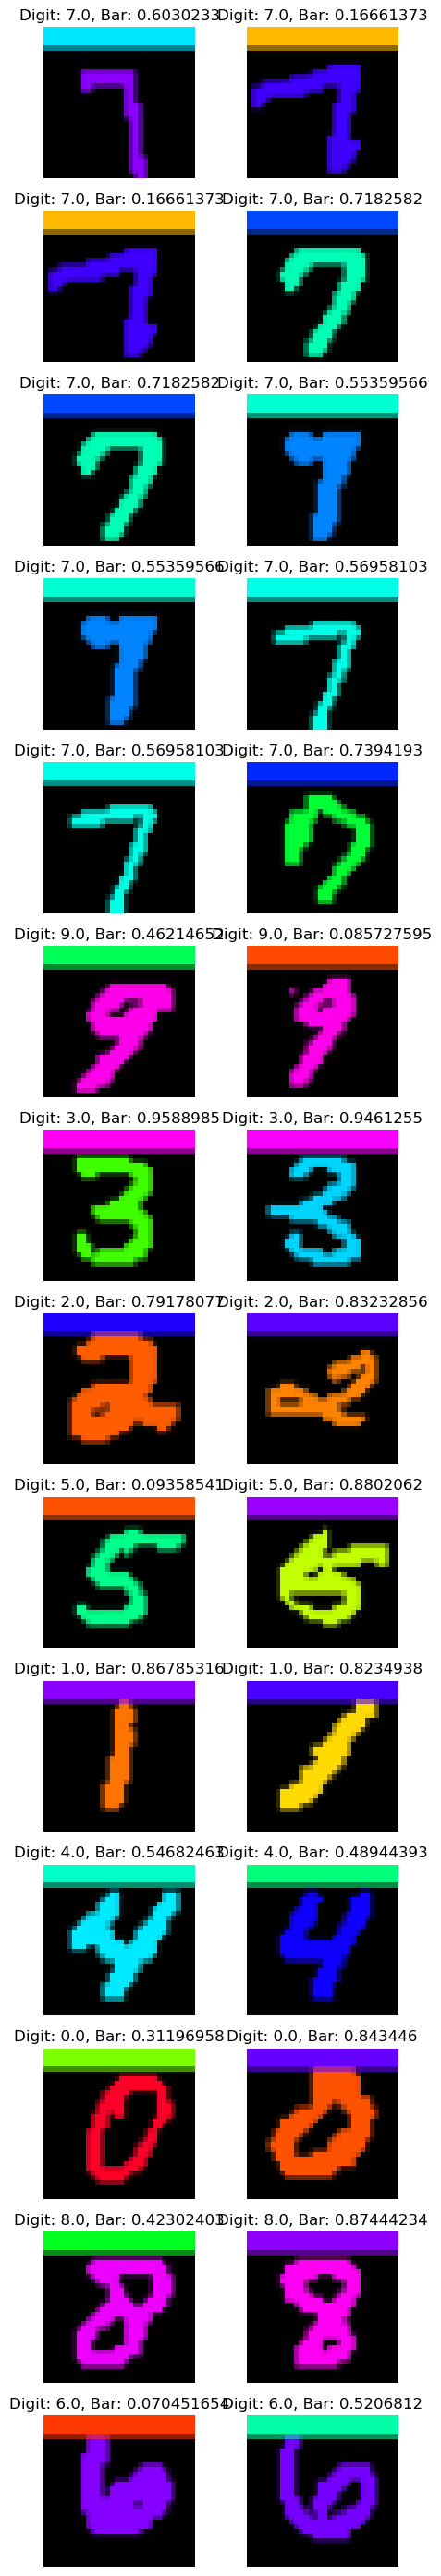

In [19]:
# Create DataLoader
dataloader = DataLoader(causal_mnist_dataset, batch_size=64, shuffle=True)

# Load a batch
batch = next(iter(dataloader))
images, distr_idxs, targets, meta_labels = batch

# Convert meta_labels to tensor
meta_labels = torch.tensor(meta_labels)

# Extract digits and color bars
digits = meta_labels[:, 0]
color_bars = meta_labels[:, 2]

# Find pairs with same digit but different color bar
digit_to_indices = {}
for idx, digit in enumerate(digits):
    digit = int(digit)
    if digit not in digit_to_indices:
        digit_to_indices[digit] = []
    digit_to_indices[digit].append(idx)

pairs = []
for digit, indices in digit_to_indices.items():
    if len(indices) > 1:
        np.random.shuffle(indices)
        for i in range(len(indices) - 1):
            idx1, idx2 = indices[i], indices[i + 1]
            if color_bars[idx1] != color_bars[idx2]:  # Ensure different color bars
                pairs.append((idx1, idx2))
            if len(pairs) >= 5:  # Collect a few pairs to visualize
                break

# Visualize some pairs
fig, axes = plt.subplots(len(pairs), 2, figsize=(5, 2 * len(pairs)))
for i, (idx1, idx2) in enumerate(pairs):
    axes[i, 0].imshow(images[idx1].permute(1, 2, 0))
    axes[i, 0].set_title(f"Digit: {digits[idx1]}, Bar: {color_bars[idx1]}")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(images[idx2].permute(1, 2, 0))
    axes[i, 1].set_title(f"Digit: {digits[idx2]}, Bar: {color_bars[idx2]}")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

In [14]:
display(causal_mnist_dataset.causal_attrs.head())

,digit,color_digit,color_bar,distr_idx
0,5,0.617777,0.541190,0
1,0,0.056087,0.926437,0
2,4,0.299589,0.745096,0
3,1,0.034136,0.707427,0
4,9,0.932498,0.739695,0


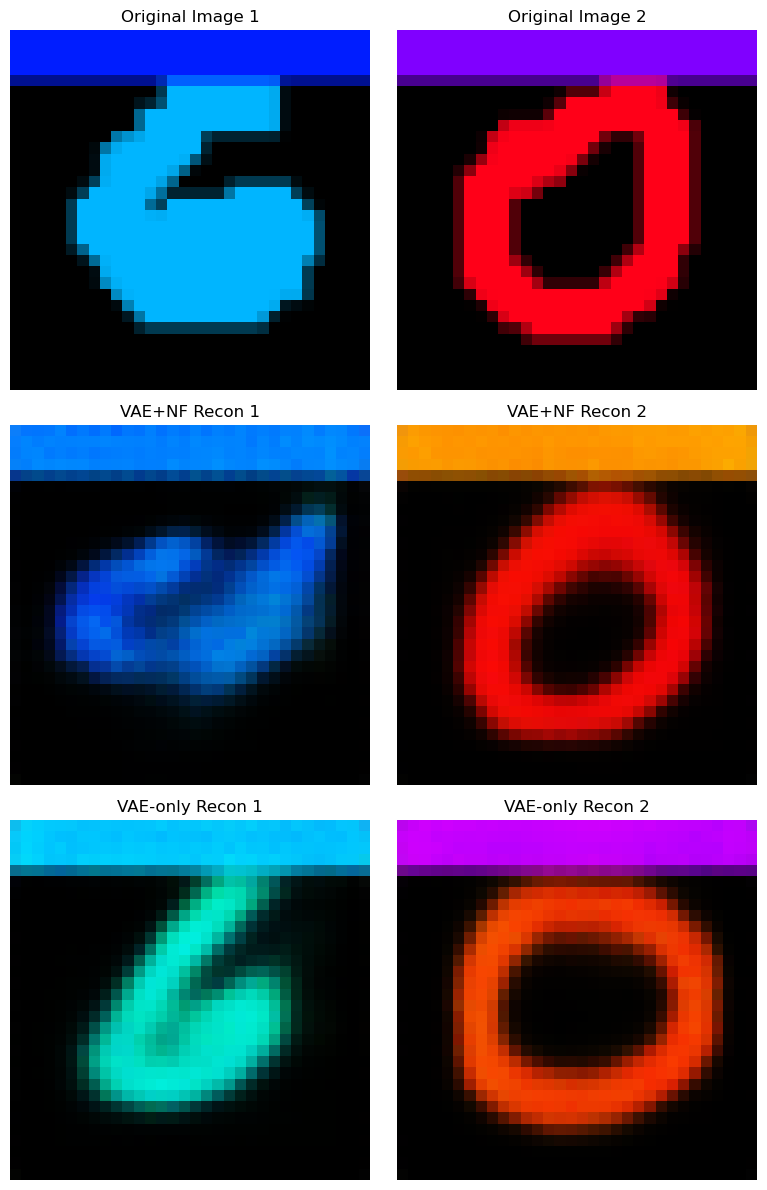

In [25]:
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

def swap_last_n_dims_pair(emb1, emb2, n=10):
    """
    Given two embedding tensors (of shape [1, D]), swap their last n dimensions.
    Returns swapped copies: (swapped_emb1, swapped_emb2).
    """
    swapped_emb1 = emb1.clone()
    swapped_emb2 = emb2.clone()
    swapped_emb1[..., -n:] = emb2[..., -n:]
    swapped_emb2[..., -n:] = emb1[..., -n:]
    return swapped_emb1, swapped_emb2

def process_and_visualize(img1, img2, vae_model, nf_model, device):
    """
    Process a pair of images:
      1. Encode via VAE (extract mu as embedding)
      2. Further encode with NF to obtain nf_embedding
      3. Swap the last 10 dimensions in the nf_embedding and decode (VAE+NF)
      4. Swap the last 10 dimensions in the VAE embedding and decode (VAE-only)
      5. Plot the original images and both reconstructions.
    """
    # Move images to device and add batch dim if needed.
    img1, img2 = img1.to(device), img2.to(device)
    img1 = img1.unsqueeze(0)  # shape: [1, C, H, W]
    img2 = img2.unsqueeze(0)

    with torch.no_grad():
        # --- VAE Encoding (we use the mean as the embedding) ---
        mu1 = vae_model.encode(img1)  # Expect (mu, logvar)
        mu2 = vae_model.encode(img2)

        vae_emb1 = mu1  # shape: [1, latent_dim]
        vae_emb2 = mu2

        # --- NF Encoding ---
        nf_emb1 = nf_model.inverse(vae_emb1)
        nf_emb2 = nf_model.inverse(vae_emb2)

        # --- Swap last 10 dims in NF embeddings ---
        swapped_nf_emb1, swapped_nf_emb2 = swap_last_n_dims_pair(nf_emb1, nf_emb2, n=10)
        # Decode swapped NF embedding via the NF inverse:
        recon_vae_emb1 = nf_model.forward(swapped_nf_emb1)
        recon_vae_emb2 = nf_model.forward(swapped_nf_emb2)
        # Decode with VAE's decoder:
        recon_img_nf_vae1 = vae_model.decode(recon_vae_emb1)
        recon_img_nf_vae2 = vae_model.decode(recon_vae_emb2)

        # --- Swap last 10 dims in VAE embeddings (directly) ---
        swapped_vae_emb1, swapped_vae_emb2 = swap_last_n_dims_pair(vae_emb1, vae_emb2, n=10)
        recon_img_vae1 = vae_model.decode(swapped_vae_emb1)
        recon_img_vae2 = vae_model.decode(swapped_vae_emb2)

    # Squeeze the batch dimension for plotting
    orig_img1 = img1.squeeze(0).cpu()
    orig_img2 = img2.squeeze(0).cpu()
    recon_img_nf_vae1 = recon_img_nf_vae1.squeeze(0).cpu()
    recon_img_nf_vae2 = recon_img_nf_vae2.squeeze(0).cpu()
    recon_img_vae1 = recon_img_vae1.squeeze(0).cpu()
    recon_img_vae2 = recon_img_vae2.squeeze(0).cpu()

    # Create a figure with 3 rows and 2 columns:
    # Row 1: Original images, Row 2: Reconstructions from VAE+NF, Row 3: Reconstructions from VAE-only.
    fig, axes = plt.subplots(3, 2, figsize=(8, 12))
    titles = [
        "Original Image 1", "Original Image 2",
        "VAE+NF Recon 1", "VAE+NF Recon 2",
        "VAE-only Recon 1", "VAE-only Recon 2"
    ]
    images = [
        orig_img1, orig_img2,
        recon_img_nf_vae1, recon_img_nf_vae2,
        recon_img_vae1, recon_img_vae2
    ]
    
    for ax, img, title in zip(axes.flatten(), images, titles):
        # If images have more than one channel, assume channels-first and permute for plotting.
        if img.shape[0] in [1, 3]:
            ax.imshow(img.permute(1, 2, 0).squeeze(), cmap='gray' if img.shape[0]==1 else None)
        else:
            ax.imshow(img.squeeze(), cmap='gray')
        ax.set_title(title)
        ax.axis("off")
    
    plt.tight_layout()
    plt.show()


# Example usage:
# Assume you have a DataLoader that yields pairs of images (or a batch from which you select two images)
# and that your vae_model, nf_model, and device are defined and loaded.
dataloader = DataLoader(causal_mnist_dataset, batch_size=2, shuffle=True)
batch = next(iter(dataloader))
images = batch[0]  # Assuming batch[0] are the images

# Process the first two images from the batch
process_and_visualize(images[0], images[1], vae_model, nf_model, device)


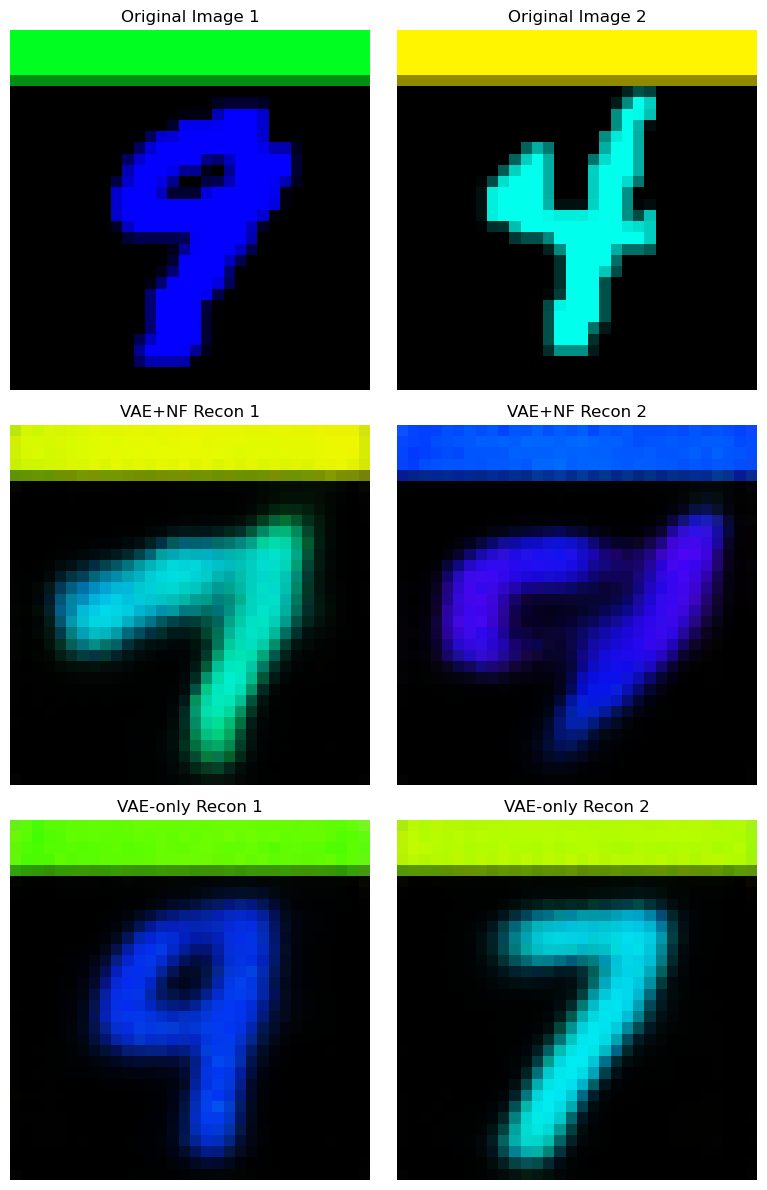

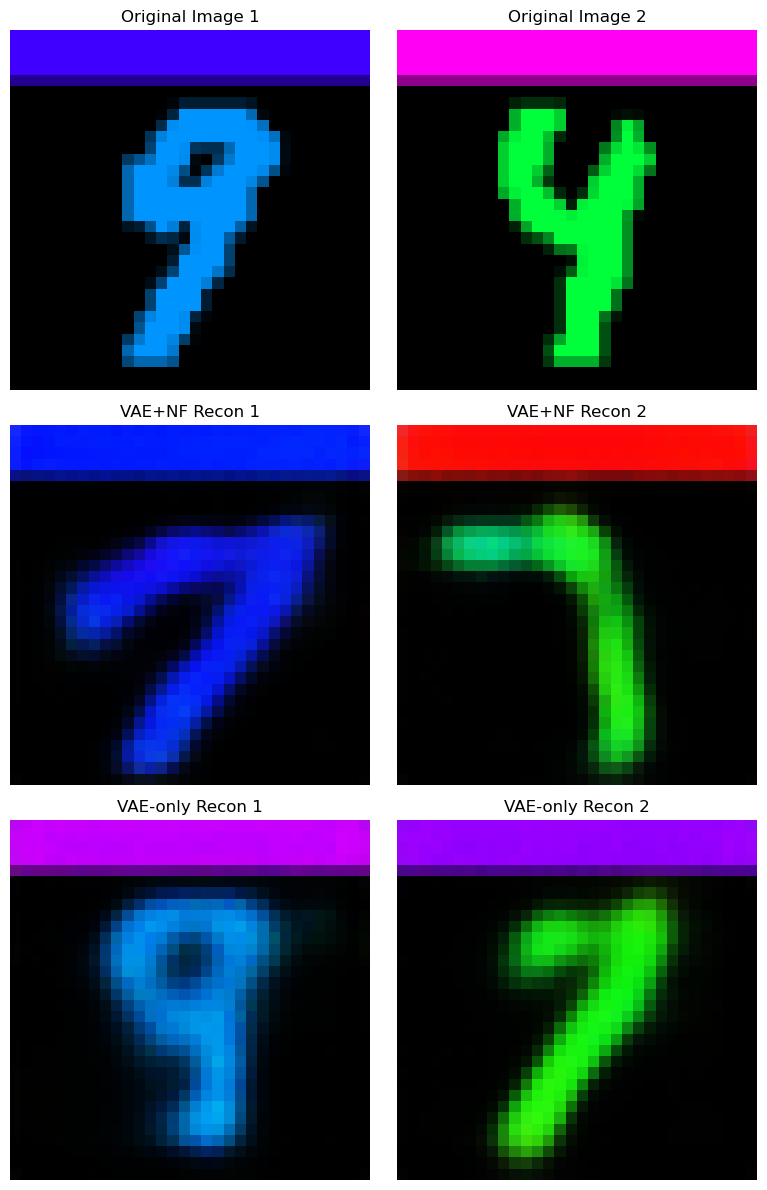

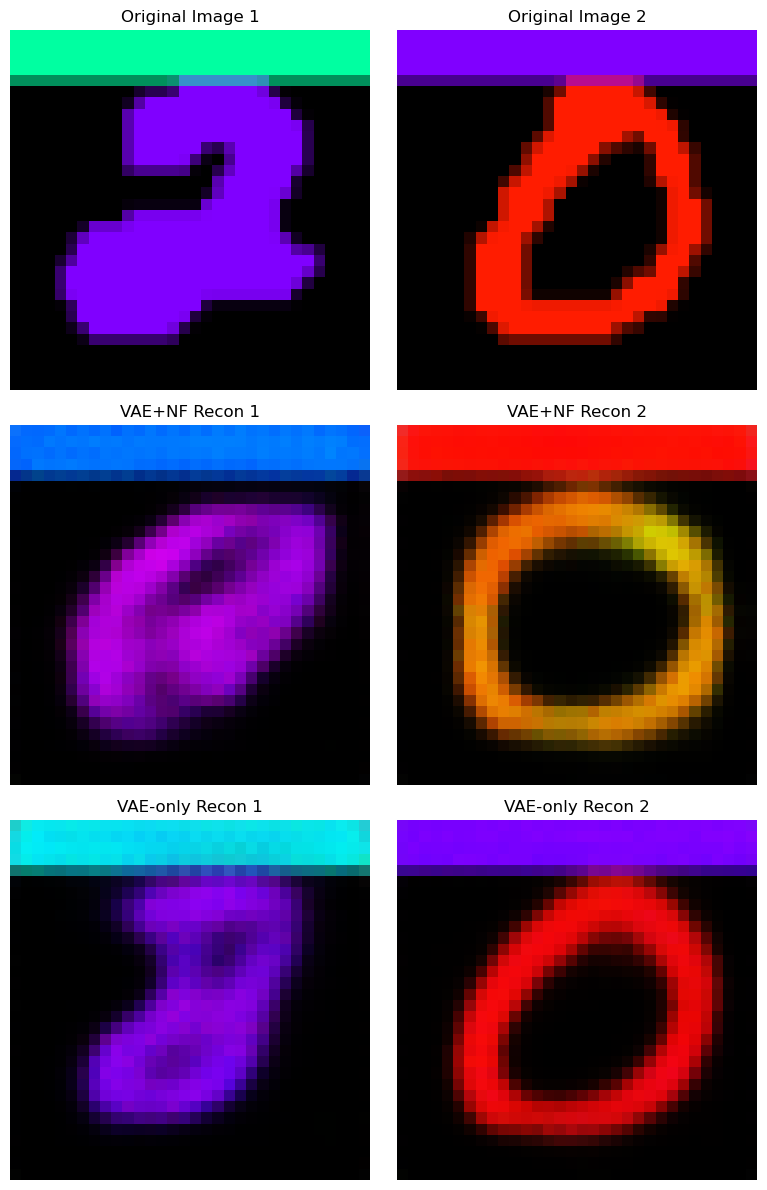

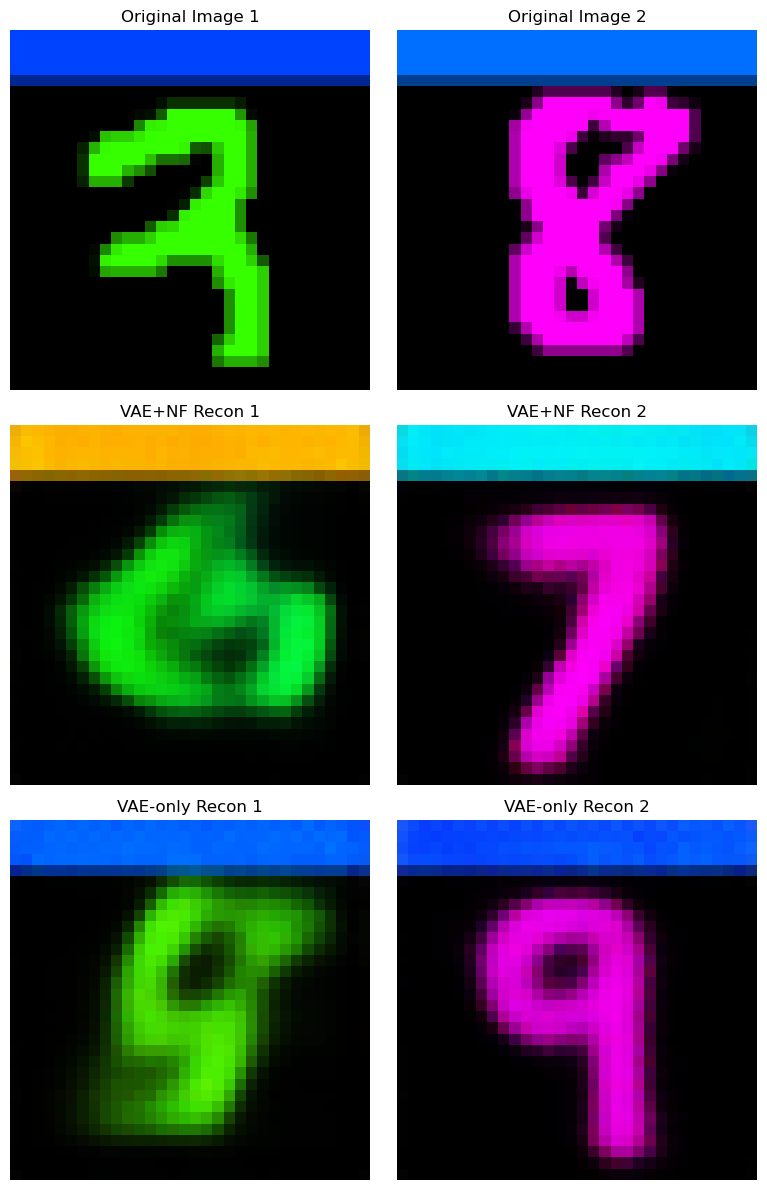

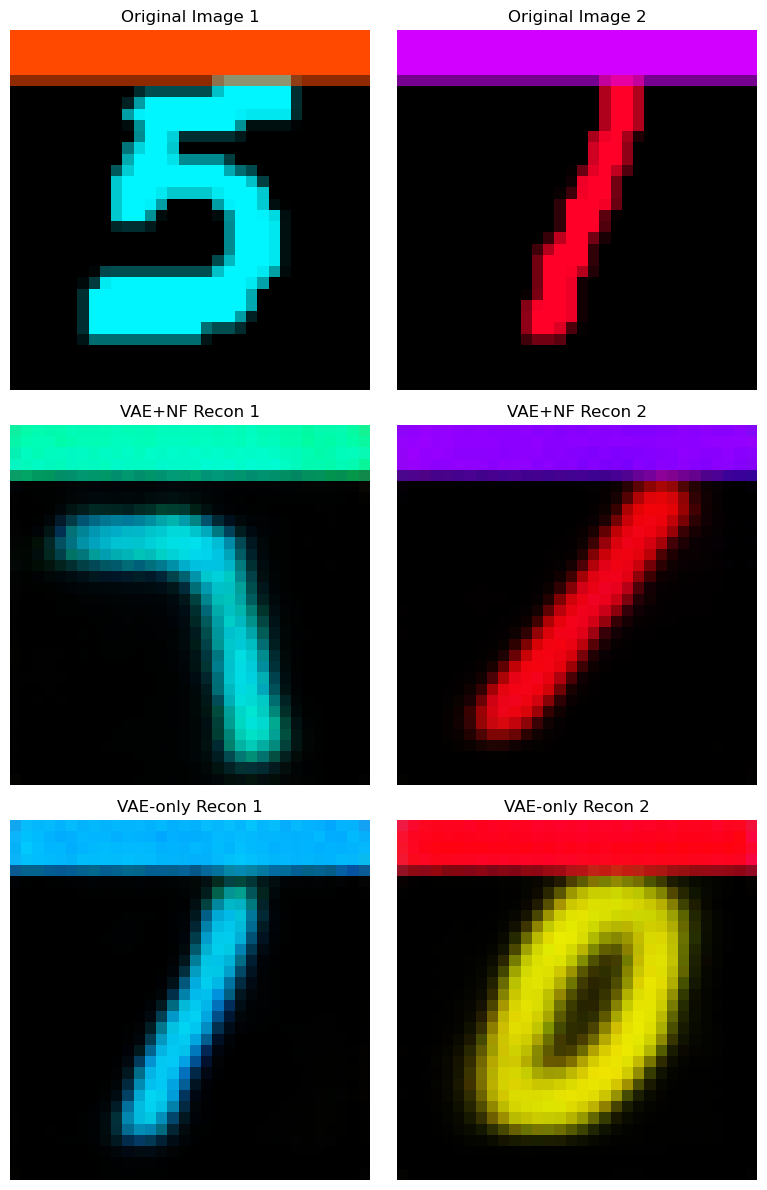

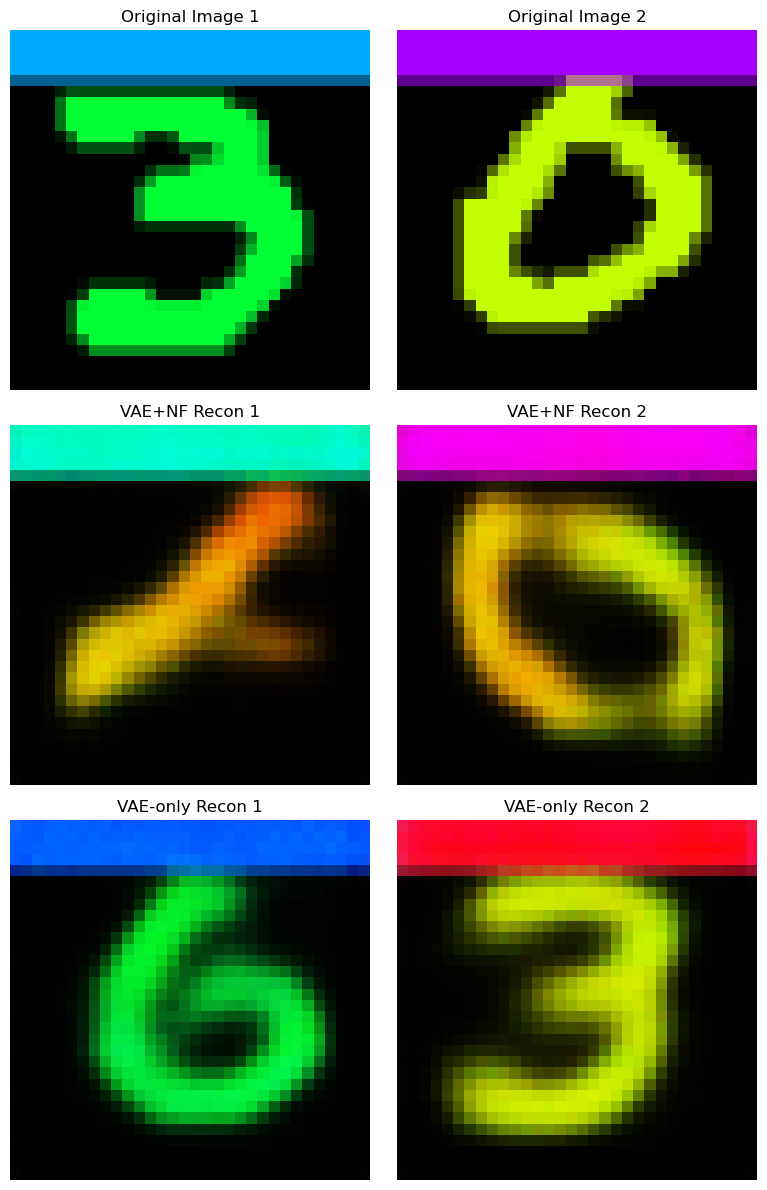

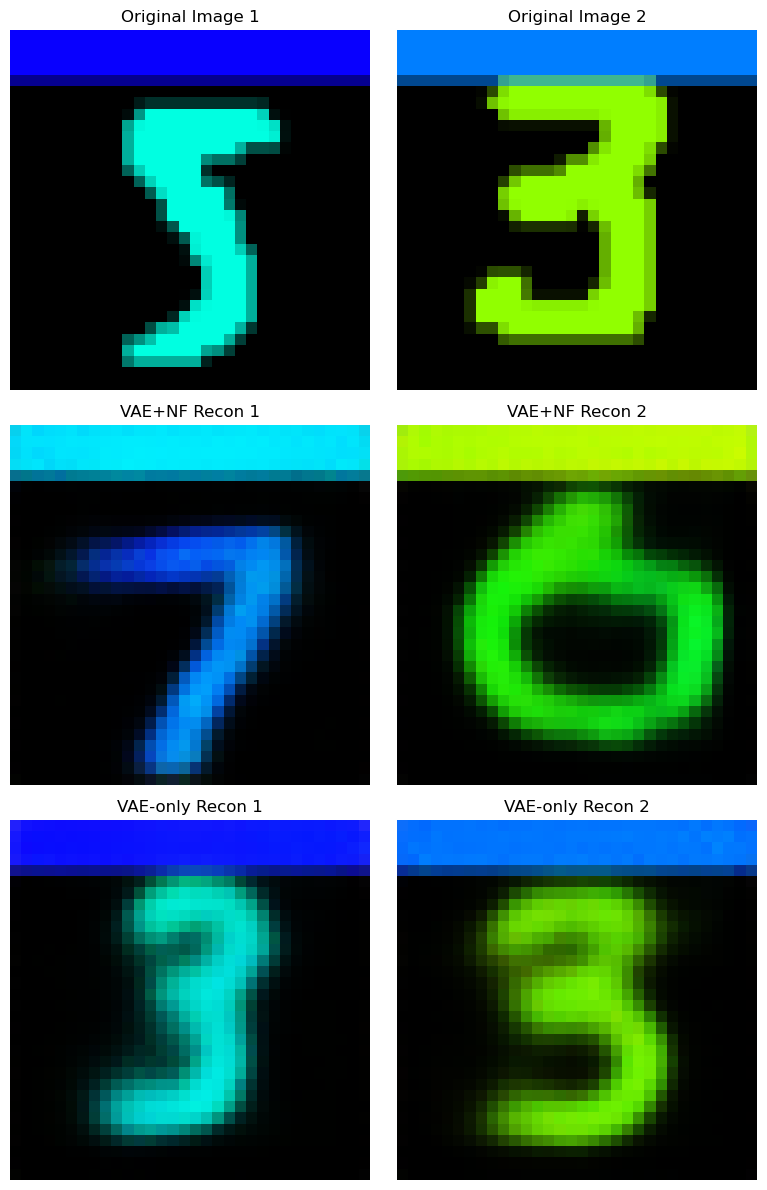

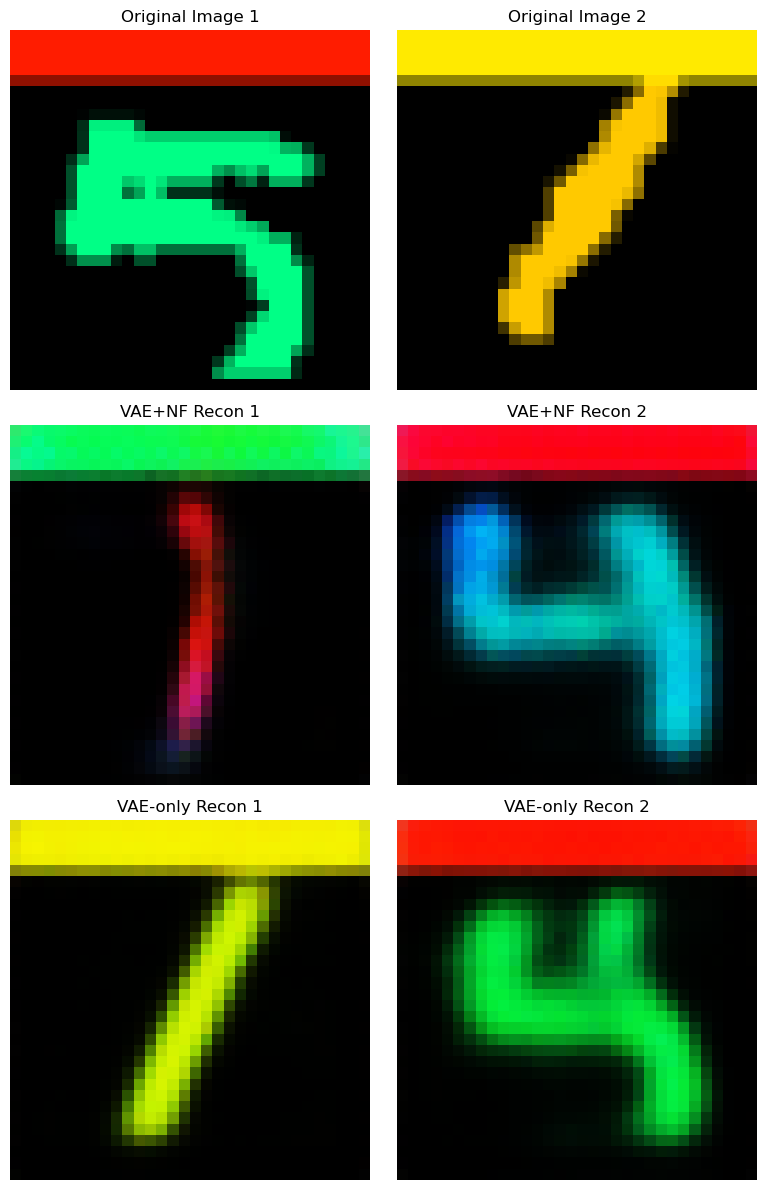

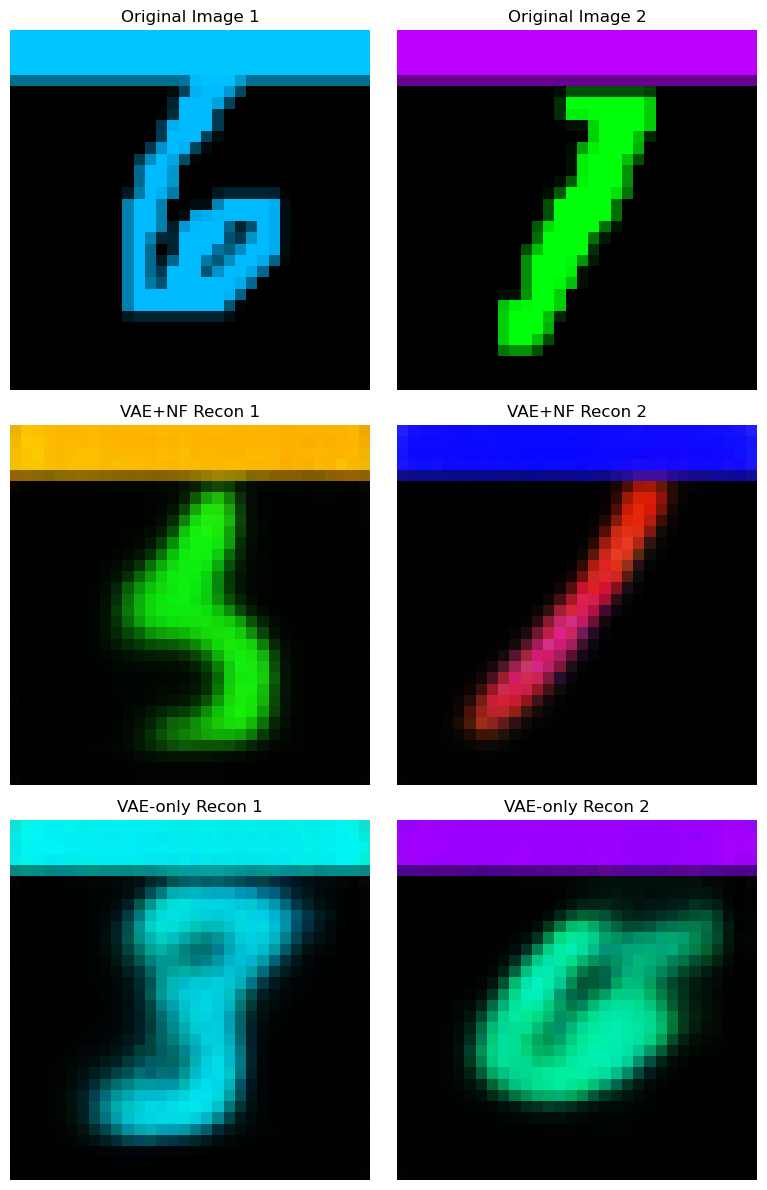

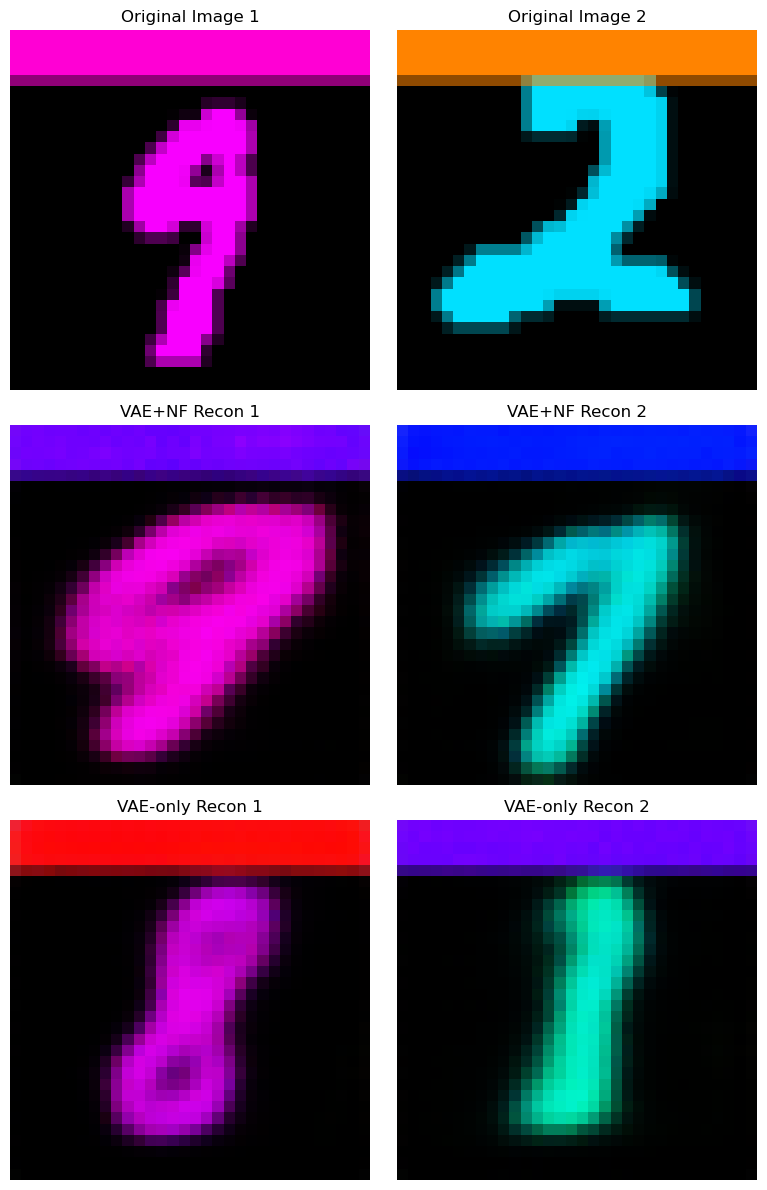

In [26]:
for idx in range(10):
    batch = next(iter(dataloader))
    images = batch[0]  # Assuming batch[0] are the images

    # Process the first two images from the batch
    process_and_visualize(images[0], images[1], vae_model, nf_model, device)


# Compare and Contrast Predicted Gender

In [ ]:
def compute_latent_space(batch_imgs, vae_model, nf_model):
    # map this batch to VAE latent space
    batch_imgs = batch_imgs.to(device)
    encoded_rep, _ = vae_model.encoder.encode(batch_imgs)

    # map VAe latent space to a causal space and apply intervention on hair color
    causal_rep = nf_model.inverse(encoded_rep)

    return causal_rep

def exchange_latent_space(img_batch_A, img_batch_B, latent_dim=48, hc_dim=4):
    img_batch_A[:, latent_dim - hc_dim : latent_dim], img_batch_B[:, latent_dim - hc_dim : latent_dim] = (
        img_batch_B[:, latent_dim - hc_dim : latent_dim],
        img_batch_A[:, latent_dim - hc_dim : latent_dim],
    )
    return img_batch_A, img_batch_B



def reconstruct_from_latent(causal_rep, vae_model, nf_model):
    # map back to VAE latent space, and then back to image space
    perturbed_encoding_rep = nf_model.forward(causal_rep)#.to(device)
    reconstructed_imgs = vae_model.decode(perturbed_encoding_rep)
    return reconstructed_imgs


# best_subset is now the most correlated with hair color, so we will perturb it
def exchange_naive_latent_space(img_batch_A, img_batch_B, best_subset):
    img_batch_A[:, best_subset], img_batch_B[:, best_subset] = (
        img_batch_B[:, best_subset],
        img_batch_A[:, best_subset],
    )
    return img_batch_A, img_batch_B

